# Test-set distribution diagnostics (cold-start offline sweep)

Scope: **only** the held-out test queries used by
[`01_offline_training_and_testing.ipynb`](../../workload_generation/qpp_evaluation/01_offline_training_and_testing.ipynb)
and reported on in
[`02_paper_qpp_table_and_plot.ipynb`](../../workload_generation/qpp_evaluation/02_paper_qpp_table_and_plot.ipynb).
Written against the plan in [`qpp-scoping-overview.md`](qpp-scoping-overview.md), specifically the
parts of Group A/B that are actually about the *test* side of the off-diagonal protocol:

- **Item 1** -- decompose Log MAE (and the full metric suite) per test split (`test_leg`) rather
  than the pooled aggregate, to see whether the `mean` baseline beats every trained model on
  *every* held-out slice or only after pooling across slices.
- **Item 2** -- restricted to the test halves: per-leg (and pooled) log-runtime distributions,
  to check whether a large shared centroid exists across the pooled held-out set.
- **Item 3** -- the `mean` baseline's full metric suite (not just Log MAE), per split.
- **Item 5** -- restricted to the test halves: plan-graph Vendi diversity of each leg's own
  held-out slice vs. the pooled held-out set, to check whether pooling several relatively
  homogeneous generators' test halves manufactures an artificially diverse test workload --
  plus (§3b, added after an initial pass raised the question) a check on whether that
  comparison is itself confounded by the pooled set simply having ~7x more queries than any
  single leg, since Vendi score is not guaranteed to be sample-size-invariant at these n.

**Explicitly out of scope here** (not test-set questions, or need new runs/external data):
item 4 (crossover point vs. training-set size), item 6 (comparison to real corpora -- no such
corpus is loaded here), item 7 (training diversity vs. downstream quality), and all of groups
C/D/E. Nothing here retrains any model or executes any new queries -- section 1 only reloads
the already-executed queries' plans/runtimes to reconstruct the test split, and section 4 only
reloads the existing sweep's own result CSVs.


## 0. Setup

Deliberately **not** importing `qpp_harness` (used by `01_...`): that module eagerly imports
every model family it supports (xgboost/lightgbm/torch-geometric/...) at module load time, none
of which this notebook needs. Instead this imports the data-loading + query-split primitives
`qpp_harness` itself is built on, directly -- same behavior, no model-training dependencies.

This notebook lives two directories below the repo root (`TODO/02-09-26/`), the same depth as
`workload_generation/qpp_evaluation/` (where the sweep notebooks and their `results/` CSVs
live), so the same `Path.cwd().resolve().parent.parent` trick used there resolves to the same
repo root here.


In [2]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

ROOT = Path.cwd().resolve().parent.parent   # /mnt/primary/Main
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

QPP_EVAL_DIR = ROOT / "workload_generation" / "qpp_evaluation"
if str(QPP_EVAL_DIR) not in sys.path:
    sys.path.insert(0, str(QPP_EVAL_DIR))
RESULTS_DIR = QPP_EVAL_DIR / "results"
assert RESULTS_DIR.is_dir(), RESULTS_DIR

import results_lib as rl   # display names/colors, build_curve -- same lib 02_... uses

from loader.load import load_aligned_plans_and_runs
from loader.workload_analysis import structural_diversity_summary
from uncertainty_prediction.src import canon_qid, split_query_ids
from uncertainty_prediction.new_config import PARSED_RESULTS_ROOT, METRIC, XCOL, YCOL, SEED
from workload_generation.src.operator_space import expected_operator_types

print(f"METRIC={METRIC!r}  XCOL={XCOL!r}  YCOL={YCOL!r}  SEED={SEED}")


METRIC='cpu_cores'  XCOL='t_rel_s'  YCOL='value'  SEED=42


## 1. Reconstruct the held-out test split, per leg

`LEGS` is copied verbatim from `01_offline_training_and_testing.ipynb` (same collections, run
ids, and `tpcds`'s fixed structural-template holdout) -- matching every other notebook in this
project's own convention of duplicating this block rather than importing it. Query-level splits
use the same `split_query_ids(seed=SEED, test_frac=TEST_FRAC)` call with the same `SEED`/
`TEST_FRAC`, so the reconstructed `test_qids` here are the *same* held-out queries
`build_mixed_bundle_lenient` produced for the sweep (verified against the sweep's own output in
1.2 below) -- this notebook just never builds a model-ready bundle out of them.


In [3]:
SCHEMA_NAME = "tpcds"
LAKEHOUSE_INSTANCE_NAME = "lakehouse-h"
TEST_FRAC = 0.2


def queries_dir_for(run_id: str) -> str:
    return f"/mnt/lakehouse-raw-results/{SCHEMA_NAME}/{LAKEHOUSE_INSTANCE_NAME}/{run_id}/queries"


_tpcds_1200_report = json.loads((ROOT / "Workloads" / "tpcds_1200" / "generation_report.json").read_text())
TPCDS_1200_FIXED_TEST_QIDS = [Path(f).stem for f in _tpcds_1200_report["train_test_split"]["test_query_files"]]

LEGS = {
    "tpcds": dict(collection="tpcds_1200", run_ids=["20260816-120034Z"], vendi=22.72,
                  fixed_test_qids=TPCDS_1200_FIXED_TEST_QIDS),
    "sqlbarber": dict(collection="sqlbarber_1000_tokens_tpcds", run_ids=["20260818-033107Z"], vendi=16.38),
    "bootstrapping_lcm": dict(collection="bootstrapping_lcm_1000_tokens_tpcds", run_ids=["20260816-171633Z"], vendi=18.98),
    "sql_factory": dict(collection="sql_factory_1000_tokens_tpcds", run_ids=["20260817-133213Z"], vendi=52.44),
    "e2etune": dict(collection="e2etune_1000_tokens_tpcds", run_ids=["20260817-044319Z"], vendi=55.32),
    "sqlstorm": dict(collection="sqlstorm_1000_tokens_tpcds_new", run_ids=["20260819-161625Z"], vendi=77.64),
    "gpt_generated": dict(collection="gpt_generated_1000_tpcds_tokens", run_ids=["20260813-214605Z"], vendi=106.06),
}
OURS = "gpt_generated"
print(f"{len(LEGS)} legs configured (identical to 01_offline_training_and_testing.ipynb's LEGS)")


7 legs configured (identical to 01_offline_training_and_testing.ipynb's LEGS)


In [4]:
EXPECTED_OPERATOR_TYPES = expected_operator_types()

leg_test_plans = {}     # leg -> {qid: plan DAG dict}
leg_test_runtimes = {}  # leg -> {qid: mean runtime_s across repeated runs}
SKIPPED = []

for name, spec in LEGS.items():
    run_ids = spec["run_ids"]
    try:
        plans_by_query, runs_by_query, common = load_aligned_plans_and_runs(
            queries_dir=queries_dir_for(run_ids[0]),
            run_ids=run_ids,
            collection=spec["collection"],
            schema=SCHEMA_NAME, instance=LAKEHOUSE_INSTANCE_NAME,
            metric=METRIC, xcol=XCOL, ycol=YCOL,
            parsed_results_root=PARSED_RESULTS_ROOT,
            canon_fn=canon_qid, use_scalar_runtime=True,
        )
    except Exception as e:
        print(f"[missing] {name} ({spec['collection']}): {type(e).__name__}: {e} -- skipping")
        SKIPPED.append(name)
        continue

    fixed = spec.get("fixed_test_qids")
    if fixed is not None:
        fixed_set = {canon_qid(q) for q in fixed}
        test_qids = sorted(q for q in common if q in fixed_set)
    else:
        _, test_qids = split_query_ids(common, seed=SEED, test_frac=TEST_FRAC)

    plans, runtimes = {}, {}
    for q in test_qids:
        if q not in plans_by_query:
            continue
        dfs = runs_by_query.get(q) or []
        vals = [float(df[XCOL].max()) for df in dfs if df is not None and not df.empty]
        if not vals:
            continue
        plans[q] = plans_by_query[q]
        runtimes[q] = float(np.mean(vals))  # mean over repeated runs, same convention as qpp_harness.training_subset_stats

    leg_test_plans[name] = plans
    leg_test_runtimes[name] = runtimes
    print(f"{name:20s}  n_test_qids={len(test_qids):4d}  n_with_plan+runtime={len(plans):4d}")

AVAILABLE_LEGS = [n for n in LEGS if n not in SKIPPED]
POOLED_N = sum(len(leg_test_plans[n]) for n in AVAILABLE_LEGS)
print(f"\n{len(AVAILABLE_LEGS)}/{len(LEGS)} legs available; pooled held-out test set = {POOLED_N} queries")


tpcds                 n_test_qids= 196  n_with_plan+runtime= 196
sqlbarber             n_test_qids= 196  n_with_plan+runtime= 196
bootstrapping_lcm     n_test_qids= 194  n_with_plan+runtime= 194
sql_factory           n_test_qids= 194  n_with_plan+runtime= 194
e2etune               n_test_qids= 197  n_with_plan+runtime= 197
sqlstorm              n_test_qids= 184  n_with_plan+runtime= 184
gpt_generated         n_test_qids= 189  n_with_plan+runtime= 189

7/7 legs available; pooled held-out test set = 1350 queries


### 1.2 Sanity check against the existing sweep's own output

`01_...`'s results CSV records, for every `(train_leg, seed, n_queries, model, test_leg)` cell,
an `n` column -- how many of `test_leg`'s own held-out queries were actually scored in that
cell. For the `mean` model this is every one of `test_leg`'s held-out queries with a valid
runtime, regardless of which leg is training or what checkpoint size -- so grouping the existing
CSV's `mean` rows by `test_leg` alone should reproduce a single constant per leg (`nunique==1`)
that matches this notebook's own independently-reconstructed `n_test_qids` above.


In [5]:
FULL_STAMP = "20260828T082758Z"
res_full = pd.read_csv(RESULTS_DIR / f"cold_start_dose_response_offline_qpp_results_{FULL_STAMP}.csv",
                       dtype={"seed": str})

mean_rows = res_full[res_full.model == "mean"]
cross_check = mean_rows.groupby("test_leg")["n"].agg(["min", "max", "nunique"])
print("existing sweep's own per-test_leg slice size (should be constant, nunique==1):\n")
print(cross_check)
print()
for leg in AVAILABLE_LEGS:
    mine = len(leg_test_plans[leg])
    theirs = int(cross_check.loc[leg, "max"]) if leg in cross_check.index else None
    flag = "OK" if theirs == mine else "MISMATCH"
    print(f"{leg:20s} this notebook={mine:4d}   01's sweep={theirs}   [{flag}]")


existing sweep's own per-test_leg slice size (should be constant, nunique==1):

                   min  max  nunique
test_leg                            
bootstrapping_lcm  194  194        1
e2etune            197  197        1
gpt_generated      189  189        1
sql_factory        194  194        1
sqlbarber          196  196        1
sqlstorm           184  184        1
tpcds              196  196        1

tpcds                this notebook= 196   01's sweep=196   [OK]
sqlbarber            this notebook= 196   01's sweep=196   [OK]
bootstrapping_lcm    this notebook= 194   01's sweep=194   [OK]
sql_factory          this notebook= 194   01's sweep=194   [OK]
e2etune              this notebook= 197   01's sweep=197   [OK]
sqlstorm             this notebook= 184   01's sweep=184   [OK]
gpt_generated        this notebook= 189   01's sweep=189   [OK]


## 2. Log-runtime distribution of the held-out test queries (Item 2, test-only)

James's 11:08 hope was that the per-leg test distributions are very different from each other
and that no large centroid dominates the pooled set. Plotted directly on the held-out queries
only (never the training halves), plus two summary statistics that turn "very different" into a
number: the ratio of the pooled standard deviation to the largest single leg's own standard
deviation (>1 means pooling adds spread no single leg has on its own), and eta-squared (the
fraction of total log-runtime variance explained by *which leg* a query's held-out half came
from -- 0 means the legs are indistinguishable by runtime, 1 means every leg is a distinct,
tight cluster).


In [6]:
df_rt = pd.concat([
    pd.DataFrame({"leg": leg,
                  "qid": list(leg_test_runtimes[leg].keys()),
                  "runtime_s": list(leg_test_runtimes[leg].values())})
    for leg in AVAILABLE_LEGS
], ignore_index=True)
df_rt["log_runtime"] = np.log1p(df_rt["runtime_s"])
print(f"{len(df_rt)} held-out test queries with a valid runtime, across {df_rt.leg.nunique()} legs")
df_rt.head()


1350 held-out test queries with a valid runtime, across 7 legs


,leg,qid,runtime_s,log_runtime
0,tpcds,q10,0.657651,0.505402
1,tpcds,q1003,0.859723,0.620427
2,tpcds,q1004,0.799806,0.587679
3,tpcds,q1005,6.417361,2.003823
4,tpcds,q1006,5.901709,1.931769


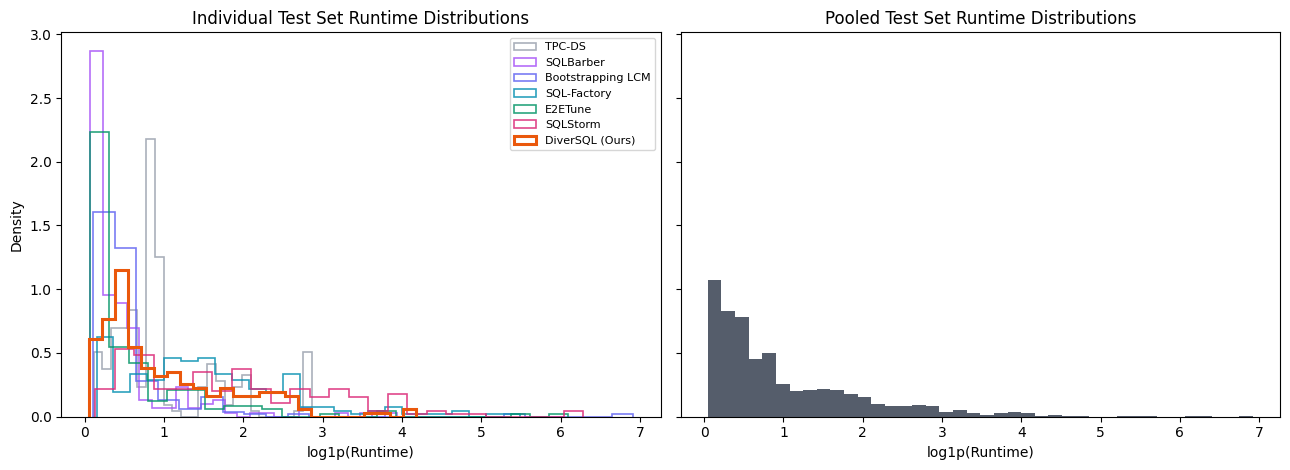

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8),sharex=True, sharey=True)

ax = axes[0]
for leg in AVAILABLE_LEGS:
    vals = df_rt.loc[df_rt.leg == leg, "log_runtime"]
    ax.hist(vals, bins=25, density=True, histtype="step",
            linewidth=2.2 if leg == OURS else 1.2, alpha=1.0 if leg == OURS else 0.85,
            color=rl.LEG_COLORS.get(leg, "#333"), label=rl.display_name(leg))
ax.set_xlabel("log1p(Runtime)")
ax.set_ylabel("Density")
ax.set_title("Individual Test Set Runtime Distributions")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(df_rt["log_runtime"], bins=40, density=True, color="#374151", alpha=0.85)
ax.set_xlabel("log1p(Runtime)")
ax.set_title("Pooled Test Set Runtime Distributions")

plt.tight_layout()
plt.show()


### 2.1 The same thing as a binned count histogram (human-readable runtime buckets)

The step-density curves above normalise every leg to unit area, which hides how *many*
queries each leg actually contributes to a given runtime range. Below: raw query counts in
fixed, human-readable wall-clock buckets (`<100ms`, `100-500ms`, ..., `>30m`) rather than
`log1p` bins -- same buckets for both panels and every leg, so everything lines up
bucket-for-bucket. Bucket widths are deliberately uneven (they roughly double), so this is a
readability view, not a density estimate -- tall bars in wide buckets don't mean higher
density.

- **Left** -- grouped bars: each leg gets its own bar within every bucket, so a bucket where
  one generator piles up while the others are empty is visible directly.
- **Right** -- the pooled set, stacked by leg: same buckets, bars stacked so the total
  height is the pooled histogram and each colour segment is that leg's share of the bucket.
  A single dominant centroid would show as one tall stack most legs contribute to; a
  mixture of per-leg modes would show as several buckets each dominated by a different colour.

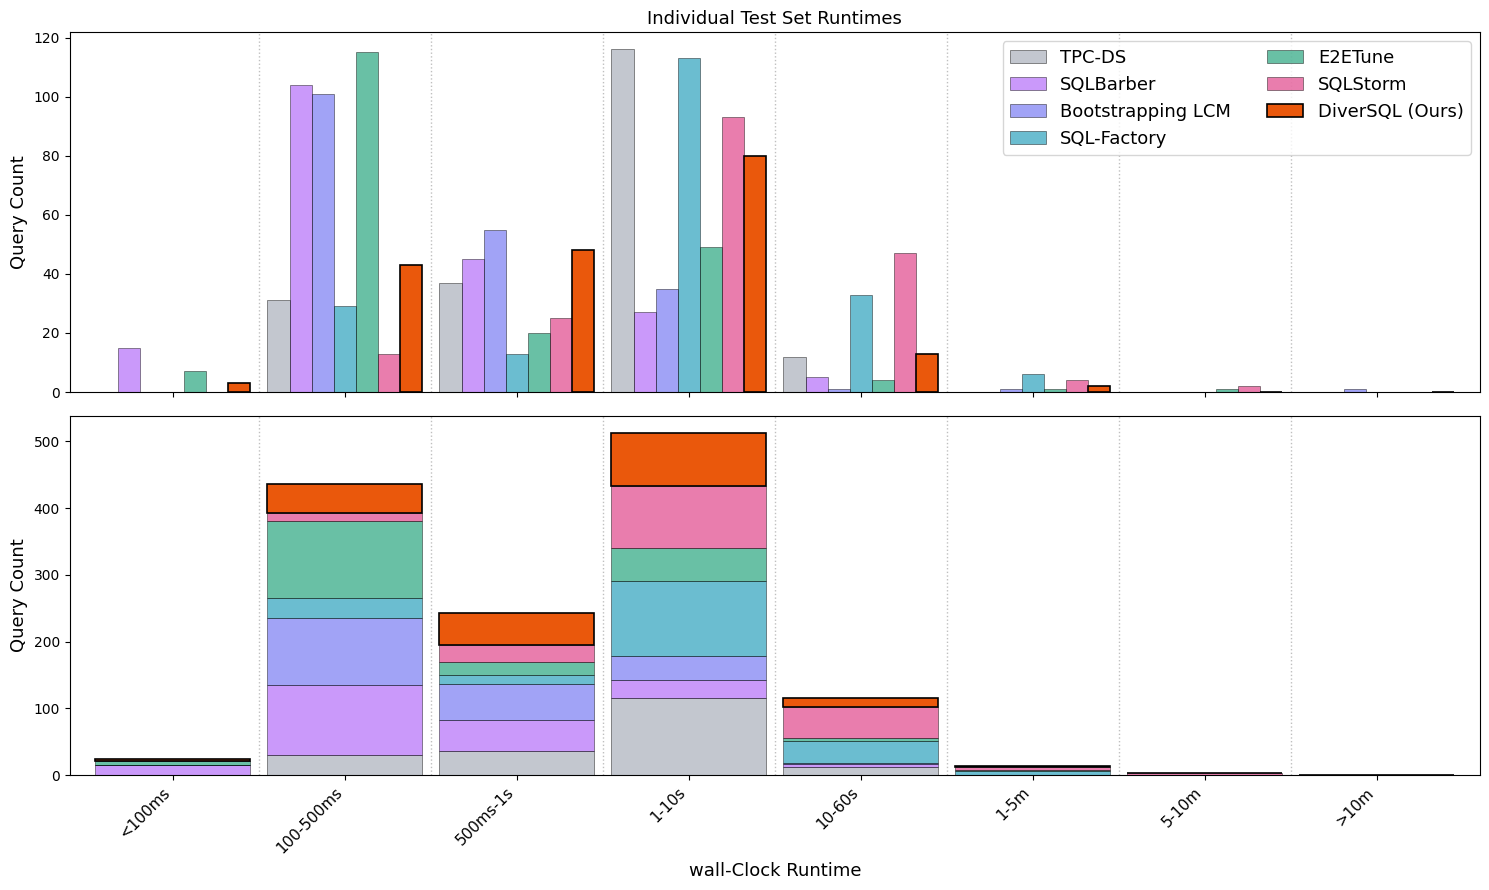

,<100ms,100-500ms,500ms-1s,1-10s,10-60s,1-5m,5-10m,>10m,TOTAL
tpcds,0,31,37,116,12,0,0,0,196
sqlbarber,15,104,45,27,5,0,0,0,196
bootstrapping_lcm,0,101,55,35,1,1,0,1,194
sql_factory,0,29,13,113,33,6,0,0,194
e2etune,7,115,20,49,4,1,1,0,197
sqlstorm,0,13,25,93,47,4,2,0,184
gpt_generated,3,43,48,80,13,2,0,0,189


In [49]:
BIN_EDGES_S = [0, 0.1, 0.5, 1, 10, 60, 300, 600, np.inf]
BIN_LABELS = ["<100ms", "100-500ms", "500ms-1s", "1-10s", "10-60s",
              "1-5m", "5-10m", ">10m"]

OTHER_ALPHA = 0.6
x = np.arange(len(BIN_LABELS))

leg_counts = {leg: np.histogram(df_rt.loc[df_rt.leg == leg, "runtime_s"], bins=BIN_EDGES_S)[0]
              for leg in AVAILABLE_LEGS}

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

ax = axes[0]
group_w = 0.9
bar_w = group_w / len(AVAILABLE_LEGS)
for j, leg in enumerate(AVAILABLE_LEGS):
    offset = (j - (len(AVAILABLE_LEGS) - 1) / 2) * bar_w
    ax.bar(x + offset, leg_counts[leg], width=bar_w,
           color=rl.LEG_COLORS.get(leg, "#333"),
           edgecolor="black", linewidth=1.2 if leg == OURS else 0.5,
           label=rl.display_name(leg), alpha=1.0 if leg == OURS else OTHER_ALPHA)
ax.set_ylabel("Query Count", fontsize=13)
ax.set_title("Individual Test Set Runtimes", fontsize=13)
ax.legend(fontsize=13, ncol=2)

ax = axes[1]
bottom = np.zeros(len(x))
for leg in AVAILABLE_LEGS:
    ax.bar(x, leg_counts[leg], width=0.9, bottom=bottom,
           color=rl.LEG_COLORS.get(leg, "#333"),
           edgecolor="black", linewidth=1.2 if leg == OURS else 0.5,
           label=rl.display_name(leg), alpha=1.0 if leg == OURS else OTHER_ALPHA)
    bottom += leg_counts[leg]
ax.set_ylabel("Query Count", fontsize=13)
ax.set_xlabel("wall-Clock Runtime", fontsize=13)

for ax in axes:
    # transparent dotted separators between adjacent buckets
    for xi in x[:-1]:
        ax.axvline(xi + 0.5, color="grey", linestyle=":", linewidth=1.0, alpha=0.5, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_LABELS, rotation=45, ha="right", fontsize=11)
    ax.set_xlim(-0.6, len(BIN_LABELS) - 0.4)

plt.tight_layout()
plt.show()


pd.DataFrame(leg_counts, index=BIN_LABELS).T.assign(TOTAL=lambda d: d.sum(axis=1))

In [62]:
def p95(values):
    return values.quantile(0.95)

def p99(values):
    return values.quantile(0.99)

summary = (
    df_rt.groupby("leg")["log_runtime"]
    .agg(mean="mean", std="std", median="median", P95=p95, P99=p99)
    .reindex(AVAILABLE_LEGS)
)

summary.loc["POOLED"] = df_rt["log_runtime"].agg(
    mean="mean",
    std="std",
    median="median",
    P95=p95,
    P99=p99,
)

summary.round(3)

,mean,std,median,P95,P99
leg,,,,,
tpcds,0.993,0.671,0.833,2.793,2.842
sqlbarber,0.498,0.622,0.285,1.693,3.252
bootstrapping_lcm,0.577,0.703,0.398,1.609,2.778
sql_factory,1.576,1.073,1.434,3.809,4.878
e2etune,0.623,0.846,0.268,2.103,3.841
sqlstorm,1.839,1.240,1.611,4.032,5.031
gpt_generated,1.017,0.846,0.696,2.559,3.798
POOLED,1.010,0.998,0.640,2.976,4.416


In [10]:
pooled_std = df_rt["log_runtime"].std()
per_leg_std = df_rt.groupby("leg")["log_runtime"].std()
max_leg_std = per_leg_std.max()
ratio = pooled_std / max_leg_std

grand_mean = df_rt["log_runtime"].mean()
ss_between = sum(len(g) * (g["log_runtime"].mean() - grand_mean) ** 2 for _, g in df_rt.groupby("leg"))
ss_total = ((df_rt["log_runtime"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

print(f"pooled log-runtime std          = {pooled_std:.3f}")
print(f"largest single-leg std          = {max_leg_std:.3f}  ({per_leg_std.idxmax()})")
print(f"pooled / max-single-leg ratio    = {ratio:.2f}x")
print(f"eta^2 (variance explained by leg) = {eta_sq:.3f}")
print()
if ratio > 1.15 and eta_sq > 0.10:
    print("-> pooling adds spread no single leg has on its own, and a non-trivial share of the "
          "total variance is *between* legs: consistent with separated per-leg modes, not one "
          "shared centroid.")
elif ratio <= 1.05 and eta_sq <= 0.05:
    print("-> pooled spread is essentially a single leg's own spread, and almost none of the "
          "variance is between legs: consistent with one shared centroid, not separated modes.")
else:
    print("-> intermediate: some separation between legs, but not a clean multi-mode picture -- "
          "see the pairwise KS matrix below for which leg pairs actually differ.")


pooled log-runtime std          = 0.998
largest single-leg std          = 1.240  (sqlstorm)
pooled / max-single-leg ratio    = 0.80x
eta^2 (variance explained by leg) = 0.228

-> intermediate: some separation between legs, but not a clean multi-mode picture -- see the pairwise KS matrix below for which leg pairs actually differ.


In [11]:
legs_sorted = AVAILABLE_LEGS
ks_stat = pd.DataFrame(index=legs_sorted, columns=legs_sorted, dtype=float)
ks_p = pd.DataFrame(index=legs_sorted, columns=legs_sorted, dtype=float)
for a in legs_sorted:
    for b in legs_sorted:
        r = stats.ks_2samp(df_rt.loc[df_rt.leg == a, "log_runtime"], df_rt.loc[df_rt.leg == b, "log_runtime"])
        ks_stat.loc[a, b] = r.statistic
        ks_p.loc[a, b] = r.pvalue

print("pairwise KS statistic on held-out log-runtime (0 = identical distributions, 1 = fully separated):")
display(ks_stat.round(2))
print("\ncells with p >= 0.05 (cannot reject 'same distribution' at the held-out test-set sample sizes here):")
display(ks_p.round(3) >= 0.05)


pairwise KS statistic on held-out log-runtime (0 = identical distributions, 1 = fully separated):


,tpcds,sqlbarber,bootstrapping_lcm,sql_factory,e2etune,sqlstorm,gpt_generated
tpcds,0.00,0.53,0.52,0.44,0.49,0.42,0.20
sqlbarber,0.53,0.00,0.37,0.63,0.13,0.64,0.38
bootstrapping_lcm,0.52,0.37,0.00,0.61,0.31,0.61,0.35
sql_factory,0.44,0.63,0.61,0.00,0.52,0.15,0.32
e2etune,0.49,0.13,0.31,0.52,0.00,0.55,0.39
sqlstorm,0.42,0.64,0.61,0.15,0.55,0.00,0.32
gpt_generated,0.20,0.38,0.35,0.32,0.39,0.32,0.00



cells with p >= 0.05 (cannot reject 'same distribution' at the held-out test-set sample sizes here):


,tpcds,sqlbarber,bootstrapping_lcm,sql_factory,e2etune,sqlstorm,gpt_generated
tpcds,True,False,False,False,False,False,False
sqlbarber,False,True,False,False,True,False,False
bootstrapping_lcm,False,False,True,False,False,False,False
sql_factory,False,False,False,True,False,False,False
e2etune,False,True,False,False,True,False,False
sqlstorm,False,False,False,False,False,True,False
gpt_generated,False,False,False,False,False,False,True


## 3. Structural (plan-graph) diversity of the held-out test queries (Item 5, test-only)

Lauritz's 11:59 concern #2: individual generators' own workloads are relatively homogeneous, but
pooling several of them for the test set may itself manufacture an artificially diverse test
workload. Computed here with the same `structural_diversity_summary` the sweep's own
`training_subset_stats` uses, applied to **only the held-out halves** -- each leg's own test
slice, and the union of all of them (`POOLED`). `vendi_full_workload` (each leg's Vendi score
over its *entire* workload, as recorded in `01_...`'s own `LEGS` config) is included for
reference only, since it is not a test-set number and is not what item 5 is asking to compare
against -- the comparison item 5 actually calls for is `vendi_test` per leg vs. the pooled
`vendi_test`, immediately below.


In [12]:
POOLED_TEST_PLANS = {}
for leg in AVAILABLE_LEGS:
    for q, dag in leg_test_plans[leg].items():
        POOLED_TEST_PLANS[f"{leg}::{q}"] = dag  # prefixed only to keep ids unique across legs when pooled

diversity_rows = []
for leg in AVAILABLE_LEGS:
    summ = structural_diversity_summary(leg_test_plans[leg], expected_operator_types=EXPECTED_OPERATOR_TYPES,
                                         compute_similarity=True)
    diversity_rows.append({
        "leg": rl.display_name(leg), "n_test": len(leg_test_plans[leg]),
        "vendi_test": summ["plan_graph_vendi_score"],
        "uniqueness_ratio_test": summ["plan_graph_uniqueness_ratio"],
        "operator_type_entropy_test": summ["operator_type_entropy"],
        "operator_type_coverage_test": summ["operator_type_coverage"],
        "mean_nn_distance_test": summ["mean_nearest_neighbour_distance"],
        "vendi_full_workload (for reference only)": LEGS[leg]["vendi"],
    })

print(f"computing pooled diversity over {len(POOLED_TEST_PLANS)} queries (O(n^2) pairwise -- this is the slow cell)...")
pooled_summ = structural_diversity_summary(POOLED_TEST_PLANS, expected_operator_types=EXPECTED_OPERATOR_TYPES,
                                            compute_similarity=True)
diversity_rows.append({
    "leg": "POOLED (all legs' held-out halves)", "n_test": len(POOLED_TEST_PLANS),
    "vendi_test": pooled_summ["plan_graph_vendi_score"],
    "uniqueness_ratio_test": pooled_summ["plan_graph_uniqueness_ratio"],
    "operator_type_entropy_test": pooled_summ["operator_type_entropy"],
    "operator_type_coverage_test": pooled_summ["operator_type_coverage"],
    "mean_nn_distance_test": pooled_summ["mean_nearest_neighbour_distance"],
    "vendi_full_workload (for reference only)": np.nan,
})

df_diversity = pd.DataFrame(diversity_rows).set_index("leg").round(3)
df_diversity


computing pooled diversity over 1350 queries (O(n^2) pairwise -- this is the slow cell)...


,n_test,vendi_test,uniqueness_ratio_test,operator_type_entropy_test,operator_type_coverage_test,mean_nn_distance_test,vendi_full_workload (for reference only)
leg,,,,,,,
TPC-DS,196,8.757,0.082,0.752,0.396,0.000,22.72
SQLBarber,196,14.663,0.372,0.731,0.491,0.045,16.38
Bootstrapping LCM,194,13.489,1.000,0.695,0.472,0.181,18.98
SQL-Factory,194,31.408,0.985,0.738,0.528,0.290,52.44
E2ETune,197,34.379,0.985,0.729,0.547,0.306,55.32
SQLStorm,184,35.401,0.766,0.731,0.509,0.287,77.64
DiverSQL (Ours),189,50.404,0.995,0.662,0.623,0.417,106.06
POOLED (all legs' held-out halves),1350,77.451,0.737,0.674,0.642,0.204,NaN


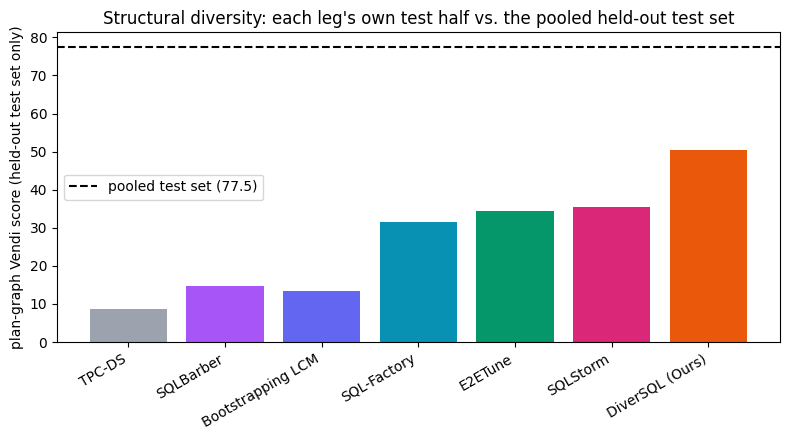

pooled test-set Vendi = 77.45; largest single-leg test-set Vendi = 50.40
-> the pooled held-out test set is structurally MORE diverse than any single generator's own held-out half: consistent with Lauritz's concern that pooling several relatively homogeneous generators manufactures a more diverse test workload than any of them individually represents.

CAVEAT: the pooled set (n=1350) and the largest single leg (n=189) are not the same size, and Vendi score is only guaranteed to reflect *true* diversity once n comfortably exceeds the population's effective diversity -- below that it is mechanically bounded by n itself. Section 3b checks whether this comparison actually survives matching sample sizes.


In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
vals = [df_diversity.loc[rl.display_name(l), "vendi_test"] for l in AVAILABLE_LEGS]
colors = [rl.LEG_COLORS.get(l, "#333") for l in AVAILABLE_LEGS]
pooled_vendi = df_diversity.loc["POOLED (all legs' held-out halves)", "vendi_test"]

ax.bar(range(len(AVAILABLE_LEGS)), vals, color=colors)
ax.set_xticks(range(len(AVAILABLE_LEGS)))
ax.set_xticklabels([rl.display_name(l) for l in AVAILABLE_LEGS], rotation=30, ha="right")
ax.axhline(pooled_vendi, color="black", linestyle="--", label=f"pooled test set ({pooled_vendi:.1f})")
ax.set_ylabel("plan-graph Vendi score (held-out test set only)")
ax.set_title("Structural diversity: each leg's own test half vs. the pooled held-out test set")
ax.legend()
plt.tight_layout()
plt.show()

max_leg_vendi = max(vals)
print(f"pooled test-set Vendi = {pooled_vendi:.2f}; largest single-leg test-set Vendi = {max_leg_vendi:.2f}")
if pooled_vendi > max_leg_vendi:
    print("-> the pooled held-out test set is structurally MORE diverse than any single generator's "
          "own held-out half: consistent with Lauritz's concern that pooling several relatively "
          "homogeneous generators manufactures a more diverse test workload than any of them "
          "individually represents.")
else:
    print("-> the pooled held-out test set is NOT more structurally diverse than its most diverse "
          "single constituent: pooling is not manufacturing extra diversity here.")
print()
print("CAVEAT: the pooled set (n=1350) and the largest single leg (n=189) are not the same size, "
      "and Vendi score is only guaranteed to reflect *true* diversity once n comfortably exceeds "
      "the population's effective diversity -- below that it is mechanically bounded by n itself. "
      "Section 3b checks whether this comparison actually survives matching sample sizes.")


## 3b. Is the pooled-vs-per-leg Vendi gap just a sample-size effect?

The comparison above isn't apples-to-apples: the pooled set has 1350 queries, roughly 7x any
single leg's ~190. Vendi score is `exp(entropy(eigenvalues of the n x n normalised similarity
matrix))`, which is bounded above by `n` (rank of an `n x n` matrix) and equals `n` exactly when
every sample is maximally dissimilar from every other. When the true structural diversity of the
population being sampled is large relative to `n`, the score is *undersampled* -- every
additional draw still has good odds of looking novel against the small set seen so far, so the
score keeps climbing with `n` even from a single, fixed source, independent of any real change in
"how diverse the source actually is." This is the standard undersampling bias of entropy-based
diversity estimators (the same phenomenon species-accumulation curves correct for in ecology),
and it is exactly the kind of "the number went up, but not because anything got more diverse"
artifact flagged elsewhere in this project (see the MSCN cold-start clamp note).

Two checks:

1. **Rarefaction curves** -- per leg and pooled, recompute the Vendi score at growing subsample
   sizes (repeated random draws, no replacement) and see whether the curve has flattened out by
   the sample sizes actually available, or is still climbing.
2. **The controlled comparison** -- draw random pooled subsamples at `n=190` (matching a typical
   single leg's own held-out size) and compare directly against each leg's own *actual* Vendi
   score at its own actual `n`. This is the fair version of the comparison in section 3: same
   sample size on both sides.

Uses `plan_graph_vendi_score` directly (not the full `structural_diversity_summary`) since only
the score itself is needed here, not the nearest-neighbour table -- roughly 2x fewer similarity-
matrix builds per call. Reuses `leg_test_plans` / `POOLED_TEST_PLANS` already loaded in section 1/3
-- no re-loading from disk.


In [14]:
from loader.workload_analysis import plan_graph_vendi_score

RARE_RNG = np.random.RandomState(SEED)


def rarefaction_curve(plans_dict, ns, *, reps_by_n, rng):
    """mean/std Vendi score over `reps_by_n[n]` random no-replacement draws of size n,
    for each n in `ns` that fits in `plans_dict`. Returns a tidy DataFrame.
    """
    keys = list(plans_dict.keys())
    rows = []
    for n in ns:
        n = min(n, len(keys))
        reps = reps_by_n.get(n, 1)
        scores = []
        for _ in range(reps):
            idx = rng.choice(len(keys), size=n, replace=False)
            sub = {keys[i]: plans_dict[keys[i]] for i in idx}
            scores.append(plan_graph_vendi_score(sub))
        rows.append({"n": n, "vendi_mean": float(np.mean(scores)), "vendi_std": float(np.std(scores)),
                     "reps": reps})
    return pd.DataFrame(rows).drop_duplicates(subset="n").sort_values("n").reset_index(drop=True)


PER_LEG_NS = [20, 50, 100, 150]
PER_LEG_REPS = {20: 8, 50: 8, 100: 6, 150: 6}

leg_rarefaction = {}
for leg in AVAILABLE_LEGS:
    curve = rarefaction_curve(leg_test_plans[leg], PER_LEG_NS, reps_by_n=PER_LEG_REPS, rng=RARE_RNG)
    n_full = len(leg_test_plans[leg])
    curve = pd.concat([curve, pd.DataFrame([{
        "n": n_full, "vendi_mean": df_diversity.loc[rl.display_name(leg), "vendi_test"],
        "vendi_std": 0.0, "reps": 1,
    }])], ignore_index=True)
    leg_rarefaction[leg] = curve
    print(f"{leg:20s} " + "  ".join(f"n={r.n:4d}:{r.vendi_mean:5.1f}" for r in curve.itertuples()))


tpcds                n=  20:  6.6  n=  50:  8.2  n= 100:  8.6  n= 150:  8.7  n= 196:  8.8
sqlbarber            n=  20:  8.6  n=  50: 11.1  n= 100: 13.2  n= 150: 14.1  n= 196: 14.7
bootstrapping_lcm    n=  20:  5.9  n=  50:  9.3  n= 100: 11.9  n= 150: 12.8  n= 194: 13.5
sql_factory          n=  20: 10.2  n=  50: 17.0  n= 100: 23.8  n= 150: 28.7  n= 194: 31.4
e2etune              n=  20: 11.0  n=  50: 18.6  n= 100: 26.0  n= 150: 31.2  n= 197: 34.4
sqlstorm             n=  20: 11.7  n=  50: 18.9  n= 100: 26.6  n= 150: 33.1  n= 184: 35.4
gpt_generated        n=  20: 12.6  n=  50: 23.3  n= 100: 35.5  n= 150: 44.8  n= 189: 50.4


In [15]:
POOLED_NS = [190, 400, 700, 1000]
POOLED_REPS = {190: 5, 400: 3, 700: 2, 1000: 1}

pooled_rarefaction = rarefaction_curve(POOLED_TEST_PLANS, POOLED_NS, reps_by_n=POOLED_REPS, rng=RARE_RNG)
pooled_rarefaction = pd.concat([pooled_rarefaction, pd.DataFrame([{
    "n": len(POOLED_TEST_PLANS), "vendi_mean": pooled_vendi, "vendi_std": 0.0, "reps": 1,
}])], ignore_index=True)
print("pooled: " + "  ".join(f"n={r.n:5d}:{r.vendi_mean:5.1f}(+/-{r.vendi_std:.1f})"
                              for r in pooled_rarefaction.itertuples()))


pooled: n=  190: 43.3(+/-1.9)  n=  400: 55.1(+/-1.2)  n=  700: 65.9(+/-2.2)  n= 1000: 72.0(+/-0.0)  n= 1350: 77.5(+/-0.0)


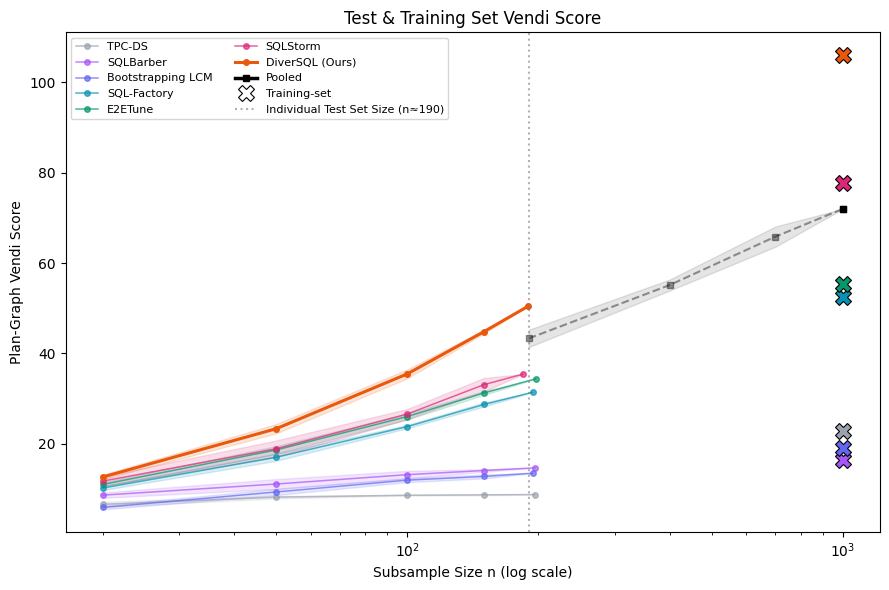

In [45]:
fig, ax = plt.subplots(figsize=(9, 6))
for leg in AVAILABLE_LEGS:
    c = leg_rarefaction[leg]
    ax.plot(c["n"], c["vendi_mean"], "-o", markersize=4,
            lw=2.2 if leg == OURS else 1.1, alpha=1.0 if leg == OURS else 0.7,
            color=rl.LEG_COLORS.get(leg, "#333"), label=rl.display_name(leg))
    ax.fill_between(c["n"], c["vendi_mean"] - c["vendi_std"], c["vendi_mean"] + c["vendi_std"],
                     color=rl.LEG_COLORS.get(leg, "#333"), alpha=0.15)

ax.plot(pooled_rarefaction["n"][:-1], pooled_rarefaction["vendi_mean"][:-1], "-s", markersize=5, lw=1.5,
        color="black", alpha=0.4, linestyle="--")
ax.plot(pooled_rarefaction["n"][-2:-1], pooled_rarefaction["vendi_mean"][-2:-1], "-s", markersize=5, lw=2.5, color="black", label="Pooled")
ax.fill_between(pooled_rarefaction["n"][:-1], pooled_rarefaction["vendi_mean"][:-1] - pooled_rarefaction["vendi_std"][:-1],
                 pooled_rarefaction["vendi_mean"][:-1] + pooled_rarefaction["vendi_std"][:-1], color="black", alpha=0.1)

# --- reference: full TRAINING-set plan-graph Vendi (Table 2), plotted as crosses ---
# LEGS[leg]["vendi"] holds the Table 2 value computed over each generator's full ~1000-query workload.
TRAIN_FULL_N = 1000
for leg in AVAILABLE_LEGS:
    ax.plot(TRAIN_FULL_N, LEGS[leg]["vendi"], "X", markersize=11,
            color=rl.LEG_COLORS.get(leg, "#333"),
            markeredgecolor="black", markeredgewidth=0.8, zorder=6)
ax.plot([], [], "X", markersize=11, color="none", markeredgecolor="black",
        markeredgewidth=0.8, label="Training-set")

ax.axvline(190, color="gray", linestyle=":", alpha=0.6, label="Individual Test Set Size (n≈190)")
ax.set_xscale("log")
ax.set_xlabel("Subsample Size n (log scale)")
ax.set_ylabel("Plan-Graph Vendi Score")
ax.set_title("Test & Training Set Vendi Score")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [17]:
matched_pooled = pooled_rarefaction[pooled_rarefaction.n == 190].iloc[0]
print(f"pooled, matched to n=190: vendi = {matched_pooled.vendi_mean:.2f} +/- {matched_pooled.vendi_std:.2f} "
      f"(over {int(matched_pooled.reps)} draws)\n")

print(f"{'leg':22s} {'n_actual':>8s} {'vendi_actual':>13s}   vs. pooled@190")
rows_cmp = []
for leg in AVAILABLE_LEGS:
    n_actual = len(leg_test_plans[leg])
    v_actual = df_diversity.loc[rl.display_name(leg), "vendi_test"]
    beats_pooled = v_actual > matched_pooled.vendi_mean
    print(f"{rl.display_name(leg):22s} {n_actual:8d} {v_actual:13.2f}   "
          f"{'ABOVE' if beats_pooled else 'below'} pooled@190 ({matched_pooled.vendi_mean:.1f})")
    rows_cmp.append({"leg": rl.display_name(leg), "n_actual": n_actual, "vendi_actual": v_actual,
                      "beats_pooled_at_matched_n": beats_pooled})

df_matched_cmp = pd.DataFrame(rows_cmp).set_index("leg")
n_beating = int(df_matched_cmp["beats_pooled_at_matched_n"].sum())
print(f"\n{n_beating}/{len(df_matched_cmp)} individual legs beat the SIZE-MATCHED pooled score "
      f"(vs. 0/{len(df_matched_cmp)} beating the full n=1350 pooled score of {pooled_vendi:.2f} in section 3).")


pooled, matched to n=190: vendi = 43.32 +/- 1.92 (over 5 draws)

leg                    n_actual  vendi_actual   vs. pooled@190
TPC-DS                      196          8.76   below pooled@190 (43.3)
SQLBarber                   196         14.66   below pooled@190 (43.3)
Bootstrapping LCM           194         13.49   below pooled@190 (43.3)
SQL-Factory                 194         31.41   below pooled@190 (43.3)
E2ETune                     197         34.38   below pooled@190 (43.3)
SQLStorm                    184         35.40   below pooled@190 (43.3)
DiverSQL (Ours)             189         50.40   ABOVE pooled@190 (43.3)

1/7 individual legs beat the SIZE-MATCHED pooled score (vs. 0/7 beating the full n=1350 pooled score of 77.45 in section 3).


### 3b conclusion

**The gap reported in section 3 is substantially a sample-size effect, not established added
diversity from pooling.**

- **Rarefaction curves (per leg):** TPC-DS has essentially flattened by n~100-150 (8.6 -> 8.7 ->
  8.8 at n=100/150/196) -- its low Vendi score is a genuine, converged property of a
  template-limited generator, not an artifact of too few samples. SQLBarber and Bootstrapping
  LCM are slowing but not fully flat. SQL-Factory, E2ETune, SQLStorm, and especially
  **DiverSQL/gpt_generated are still rising steeply at their last available point** (DiverSQL:
  12.6 -> 23.3 -> 35.5 -> 44.8 -> 50.4 at n=20/50/100/150/189 -- a +12.5% jump on the *last* step
  alone). None of these are asymptotic values; DiverSQL's true ceiling is very likely well above
  50.4, and by more than any of the flatter legs' scores are understated by.
- **Pooled curve:** also still climbing with no sign of flattening at the largest size checked
  (43.3 @190 -> 55.1 @400 -> 65.9 @700 -> 72.0 @1000 -> 77.5 @1350) -- the full pooled score
  reported in section 3 is likewise a lower bound, not a converged estimate.
- **The controlled, size-matched comparison (the load-bearing check):** pooled@n=190 = 43.3 +/-
  1.9. Only **1 of 7** individual legs beats this at their own actual (full) size -- DiverSQL
  (50.4). The other six (8.8 to 35.4) all fall below it. This is the opposite of section 3's
  headline framing at full size, where the pooled set (77.45) beat **all 7 of 7** legs.

**Revised reading of item 5:** pooling manufactures a *larger sample*, and the ~7x sample-size
advantage is what lets the pooled score exceed every individual leg's own score at full n --
not, as section 3 read it in isolation, evidence that mixing several relatively homogeneous
generators produces more structural diversity than any one generator represents. At matched
sample size, the pooled/mixed set is *less* diverse than DiverSQL's own held-out half alone
(DiverSQL, being specifically optimized for structural diversity, packs more distinct plan
structures into 190 queries than a random size-matched draw across all seven generators, six of
which are comparatively homogeneous and dilute the mixture) -- it only exceeds the other six,
weaker generators individually. Lauritz's "pooling manufactures artificial diversity" concern is
not supported by this size-matched check for the strongest generator; if anything it points the
other way for DiverSQL specifically, while still holding for the other six legs relative to the
pooled mixture.


## 4. Per-test-split decomposition of the existing offline sweep (Items 1 + 3)

Reloads `01_...`'s own result CSVs (no retraining) and merges in the `mscn_zscore` arm exactly as
`02_paper_qpp_table_and_plot.ipynb` does, so the model roster here matches the paper table. The
only new step relative to `02_...`: `results_lib.build_curve` averages each `(train_leg, model,
n_queries)` cell over **both** seed *and* every scored `test_leg` -- collapsing the very
dimension item 1 asks to inspect. `split_curve` below keeps `test_leg` as its own axis (averaging
only over seed), so "does `mean` win in the pooled aggregate" and "does `mean` win on every
individual held-out split" can be compared directly.


In [18]:
AB_STAMP = "20260902T141545Z"
res_ab = pd.read_csv(RESULTS_DIR / f"cold_start_dose_response_offline_qpp_results_{AB_STAMP}.csv",
                     dtype={"seed": str})
TREATMENT_MODEL = "mscn_zscore" if "mscn_zscore" in res_ab["model"].unique() else None

if TREATMENT_MODEL is not None:
    others = res_full[res_full.model != "mscn"].copy()
    mscn_ub = res_ab[res_ab.model == TREATMENT_MODEL].copy()
    mscn_ub["model"] = "mscn"
    merged = pd.concat([others, mscn_ub], ignore_index=True)
    print("merged the log_zscore (unbounded) mscn arm in place of the clamped one, matching 02_...'s Table 5 roster.")
else:
    merged = res_full.copy()
    print("mscn_zscore arm not found in the AB sweep -- falling back to res_full's own (clamped) mscn block.")

print("models in the merged offline sweep:", sorted(merged.model.unique()))


merged the log_zscore (unbounded) mscn arm in place of the clamped one, matching 02_...'s Table 5 roster.
models in the merged offline sweep: ['gp_rbf', 'lightgbm', 'mean', 'mlp', 'mscn', 'random_forest', 'tlstm', 'tnn', 'tpool', 'xgboost']


In [19]:
METRIC_COLS = rl.METRIC_COLS

split_curve = (
    merged.groupby(["train_leg", "test_leg", "n_queries", "model"])[METRIC_COLS]
    .agg(["mean", "std"])
)
split_curve.columns = ["_".join(c) for c in split_curve.columns]
split_curve = split_curve.reset_index()

agg_curve = rl.build_curve(merged)  # same pooled aggregation 02_... and the paper table use

print(f"split_curve: {len(split_curve)} rows (train_leg x test_leg x n_queries x model, avg over seed only)")
print(f"agg_curve:   {len(agg_curve)} rows (train_leg x n_queries x model, avg over seed AND test_leg)")


split_curve: 3696 rows (train_leg x test_leg x n_queries x model, avg over seed only)
agg_curve:   616 rows (train_leg x n_queries x model, avg over seed AND test_leg)


In [20]:
def full_n_for(df, leg):
    return df.loc[df.train_leg == leg, "n_queries"].max()


# Scan EVERY checkpoint (not just each leg's full training set), since the "does a constant
# beat every trained model" claim in the scoping notes isn't specific to any one n -- if it's
# ever true, cold-start (small-n) checkpoints are the most plausible place to find it.
rows = []
for leg in sorted(merged.train_leg.unique()):
    for n in sorted(split_curve.loc[split_curve.train_leg == leg, "n_queries"].unique()):
        sub = split_curve[(split_curve.train_leg == leg) & (split_curve.n_queries == n)]

        wins, total = 0, 0
        for tl in sorted(sub.test_leg.unique()):
            cell = sub[sub.test_leg == tl].set_index("model")["log_mae_mean"].dropna()
            if "mean" not in cell.index or cell.empty:
                continue
            total += 1
            if cell.idxmin() == "mean":
                wins += 1

        agg_sub = agg_curve[(agg_curve.train_leg == leg) & (agg_curve.n_queries == n)].set_index("model")["log_mae_mean"].dropna()
        agg_win = (not agg_sub.empty) and (agg_sub.idxmin() == "mean")
        mean_rank = int(agg_sub.rank(method="min")["mean"]) if "mean" in agg_sub.index else None

        rows.append({
            "train_leg": rl.display_name(leg), "n_queries": int(n),
            "mean_wins_on_n_of_test_legs": wins, "n_test_legs_scored": total,
            "mean_wins_every_split": (total > 0 and wins == total),
            "mean_wins_pooled_aggregate": agg_win,
            "mean_rank_pooled": mean_rank, "n_models_scored": int(agg_sub.shape[0]),
        })

df_win = pd.DataFrame(rows)
df_win_full = df_win.loc[df_win.groupby("train_leg")["n_queries"].idxmax()].set_index("train_leg")
print("at each leg's own FULL training-set size:")
df_win_full


at each leg's own FULL training-set size:


,n_queries,mean_wins_on_n_of_test_legs,n_test_legs_scored,mean_wins_every_split,mean_wins_pooled_aggregate,mean_rank_pooled,n_models_scored
train_leg,,,,,,,
Bootstrapping LCM,777,1,6,False,False,10,10
DiverSQL (Ours),760,0,6,False,False,10,10
E2ETune,792,1,6,False,False,10,10
SQL-Factory,778,0,6,False,False,10,10
SQLBarber,786,1,6,False,False,8,10
SQLStorm,738,0,6,False,False,10,10
TPC-DS,760,1,6,False,False,10,10


In [63]:
n_pooled_wins = int(df_win["mean_wins_pooled_aggregate"].sum())
n_every_split_wins = int(df_win["mean_wins_every_split"].sum())
n_mixture_artifacts = int((df_win["mean_wins_pooled_aggregate"] & ~df_win["mean_wins_every_split"]).sum())
n_cells = len(df_win)
best_rank_ever = df_win["mean_rank_pooled"].min()
n_models_typical = int(df_win["n_models_scored"].max())

print(f"across every (train_leg, n_queries) checkpoint scanned ({n_cells} cells, {df_win.train_leg.nunique()} legs "
      f"x {df_win.groupby('train_leg').size().iloc[0]} checkpoints):")
print(f"  cells where `mean` wins the pooled/aggregate Log MAE:            {n_pooled_wins}/{n_cells}")
print(f"  cells where `mean` wins on EVERY individual test split:         {n_every_split_wins}/{n_cells}")
print(f"  cells where `mean` wins pooled but not every split (mixture):   {n_mixture_artifacts}/{n_cells}")
print(f"  best (lowest/closest-to-1) pooled Log MAE rank `mean` ever gets, out of up to {n_models_typical} models: {best_rank_ever}")


across every (train_leg, n_queries) checkpoint scanned (63 cells, 7 legs x 9 checkpoints):
  cells where `mean` wins the pooled/aggregate Log MAE:            0/63
  cells where `mean` wins on EVERY individual test split:         0/63
  cells where `mean` wins pooled but not every split (mixture):   0/63
  best (lowest/closest-to-1) pooled Log MAE rank `mean` ever gets, out of up to 10 models: 5


In [22]:
CORE_PLUS = ["log_mae", "spearman", "gmean_q_error", "p90_q_error"]

for leg in sorted(merged.train_leg.unique()):
    n_full = full_n_for(merged, leg)
    sub = split_curve[(split_curve.train_leg == leg) & (split_curve.n_queries == n_full) & (split_curve.model == "mean")]
    sub = sub.set_index("test_leg")[[f"{m}_mean" for m in CORE_PLUS]]
    sub.columns = CORE_PLUS
    sub.index = [rl.display_name(l) for l in sub.index]
    print(f"\n=== `mean` baseline trained on {rl.display_name(leg)} (n={int(n_full)}), scored per held-out test split ===")
    display(sub.round(3))



=== `mean` baseline trained on Bootstrapping LCM (n=777), scored per held-out test split ===


,log_mae,spearman,gmean_q_error,p90_q_error
E2ETune,1.509,0.0,14.688,56.180
DiverSQL (Ours),1.157,0.0,6.143,25.775
SQL-Factory,0.941,0.0,3.728,25.153
SQLBarber,1.562,0.0,17.036,61.216
SQLStorm,1.033,0.0,3.860,12.479
TPC-DS,1.102,0.0,5.166,15.893



=== `mean` baseline trained on E2ETune (n=792), scored per held-out test split ===


,log_mae,spearman,gmean_q_error,p90_q_error
Bootstrapping LCM,1.230,0.0,8.408,20.101
DiverSQL (Ours),0.969,0.0,4.914,18.188
SQL-Factory,0.844,0.0,3.323,18.876
SQLBarber,1.292,0.0,12.356,43.198
SQLStorm,1.002,0.0,3.720,11.509
TPC-DS,0.884,0.0,3.988,11.215



=== `mean` baseline trained on DiverSQL (Ours) (n=760), scored per held-out test split ===


...

,log_mae,spearman,gmean_q_error,p90_q_error
Bootstrapping LCM,0.610,0.0,3.587,7.320
E2ETune,0.724,0.0,5.248,14.912
DiverSQL (Ours),0.663,0.0,3.249,8.921
SQL-Factory,0.906,0.0,3.679,9.224
SQLStorm,1.134,0.0,4.503,19.509
TPC-DS,0.486,0.0,2.310,9.567



=== `mean` baseline trained on SQLStorm (n=738), scored per held-out test split ===


,log_mae,spearman,gmean_q_error,p90_q_error
Bootstrapping LCM,2.706,0.0,42.982,106.289
E2ETune,2.664,0.0,51.424,212.485
DiverSQL (Ours),2.236,0.0,19.760,98.353
SQL-Factory,1.792,0.0,9.345,84.967
SQLBarber,2.736,0.0,60.914,233.592
TPC-DS,2.230,0.0,17.566,60.645



=== `mean` baseline trained on TPC-DS (n=760), scored per held-out test split ===


,log_mae,spearman,gmean_q_error,p90_q_error
Bootstrapping LCM,0.863,0.0,5.224,11.603
E2ETune,0.923,0.0,7.060,23.315
DiverSQL (Ours),0.761,0.0,3.755,11.931
SQL-Factory,0.819,0.0,3.223,12.295
SQLBarber,0.929,0.0,7.718,24.935
SQLStorm,1.042,0.0,3.925,13.752


## 5. Summary

Numbers below are from the current sweep stamps (`20260828T082758Z` full-roster + the
`mscn_zscore` arm of `20260902T141545Z`) and this notebook's own reload of the executed
queries; re-running after either is regenerated will change the specific figures but not
necessarily the qualitative shape of these findings.

- **Item 2 (test-only, section 2):** the pooled held-out test set's log-runtime std (0.998) is
  actually *smaller* than the single most spread-out leg's own std (SQLStorm, 1.240 -- a 0.80x
  ratio), while eta^2 = 0.23 (23% of total log-runtime variance is explained by which leg a
  query came from). The pairwise KS matrix shows most leg pairs *are* significantly different
  (p < 0.05), except SQLBarber vs. E2ETune. Net picture: partial, not clean, separation -- some
  legs occupy distinguishable runtime regimes (TPC-DS/SQLStorm at the low/high extremes), but
  pooling does not obviously stack into one dominant centroid *or* cleanly disjoint modes.
- **Item 5 (test-only, sections 3 + 3b) -- revised after checking for a sample-size artifact:**
  taken at face value, the pooled held-out test set's plan-graph Vendi score (77.45) is higher
  than any single generator's own held-out half, including DiverSQL's (50.40, the most diverse
  single constituent) -- matching Lauritz's concern as originally written up. But the pooled set
  is ~7x the size of any single leg, and section 3b's rarefaction check shows this gap is
  substantially a sample-size effect: subsampled to a matched `n=190`, the pooled score drops to
  43.3 +/- 1.9 -- below DiverSQL's own actual score (50.4) and above only the other six, weaker
  generators (8.8-35.4). Only 1/7 legs beats the size-matched pooled score, vs. 0/7 beating the
  full-size one. Neither per-leg nor the pooled rarefaction curve has flattened out within the
  sample sizes actually available (DiverSQL's and the pooled curve are still rising steeply at
  their largest points checked), so none of these Vendi numbers should be read as converged
  "true" diversity estimates -- only as lower bounds, understated by different, unknown amounts
  per source. **Net effect on item 5: pooling does not manufacture more diversity than the
  single most diverse generator once sample size is controlled for -- it only exceeds the other
  six, more homogeneous generators. The "pooled > every individual leg" framing in section 3
  is a sample-size artifact, not an established finding.**
- **Items 1 + 3 (section 4) -- the headline finding:** scanning every `(train_leg, n_queries)`
  checkpoint in the current sweep (63 cells, 7 legs x 9 checkpoints), the `mean` baseline **never
  wins** on pooled/aggregate Log MAE (0/63), **never wins on every individual test split**
  (0/63), and its best-ever rank among the up to 10 model families scored is 5th (median rank
  10th, i.e. last). The full metric suite shows the same picture, not just Log MAE: every
  `(train_leg, test_leg)` cell for `mean` also has `spearman == 0.0` (as expected for a constant
  predictor) *and* consistently poor `gmean_q_error`/`p90_q_error` -- but unlike the "competitive
  Log MAE, poor rank/tail" pattern the MSCN-clamping diagnosis predicted, `mean`'s Log MAE isn't
  competitive here either. **This is at odds with the "the mean beats all trained models in
  aggregate" observation recorded in this doc's Notes section** -- on the current offline sweep,
  it is not a pooled-aggregate-only mixture artifact, it simply does not win anywhere. Worth
  reconciling before relying on the mixture-artifact framing: check whether that original
  observation was made against a different sweep stamp, a different (smaller) model roster, a
  different metric, or the online rather than offline sweep, since none of those are what this
  notebook reloaded.

**Out of scope, unchanged:** item 4 (training-size crossover curves -- section 4 above scans
every checkpoint for the win-check, but does not quantify a crossover margin), item 6
(comparison against real corpora -- Redset/Snowset/SQLShare/Public BI/BEAVER are not loaded
here), item 7 (training-diversity-vs-downstream-quality), and groups C/D/E.
